EXPERIMENT 15
Multi-Agent Reinforcement Learning and POMDP Simulation


SAMPLE MULTI-AGENT DATASET


,Episode,Step,Agent,Old_Row,Old_Column,New_Row,New_Column,Action,Visible_Targets
0,1,1,1,6,3,5,3,0,1
1,1,1,2,4,6,3,6,0,1
2,1,1,3,2,7,2,6,2,1
3,1,2,1,5,3,6,3,1,1
4,1,2,2,3,6,2,6,0,1
5,1,2,3,2,6,3,6,1,1
6,1,3,1,6,3,5,3,0,1
7,1,3,2,2,6,3,6,1,1
8,1,3,3,3,6,2,6,0,1
9,1,4,1,5,3,6,3,1,1


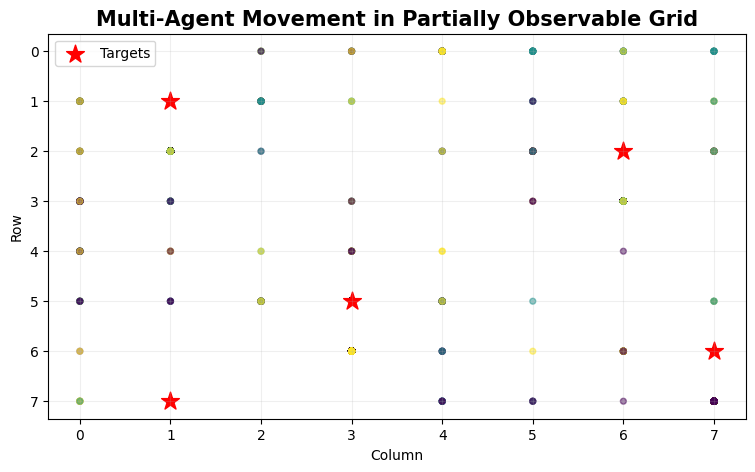

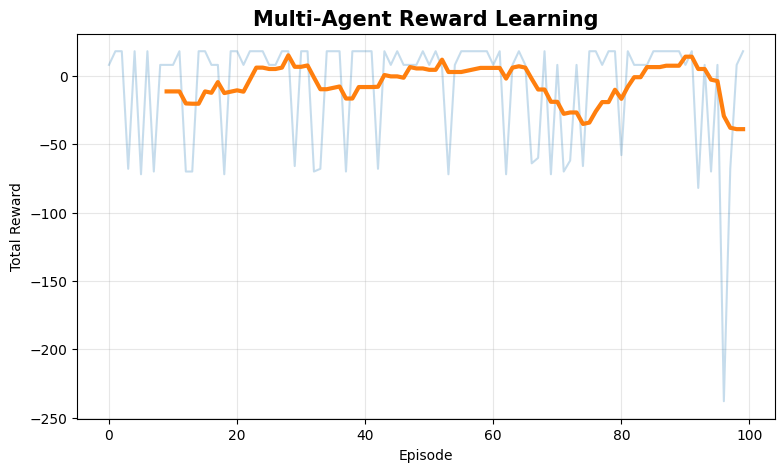

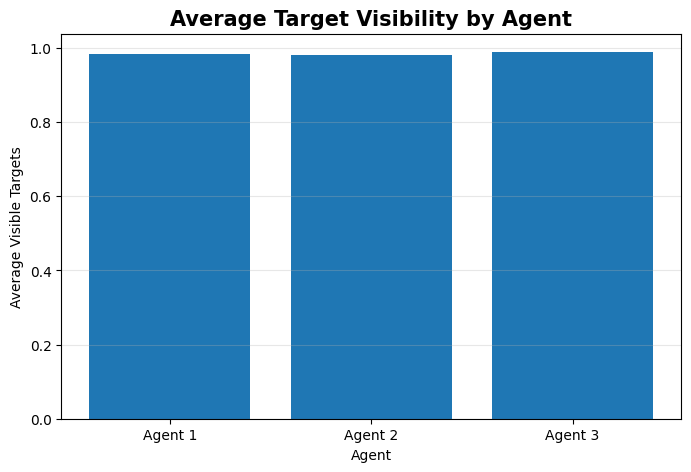

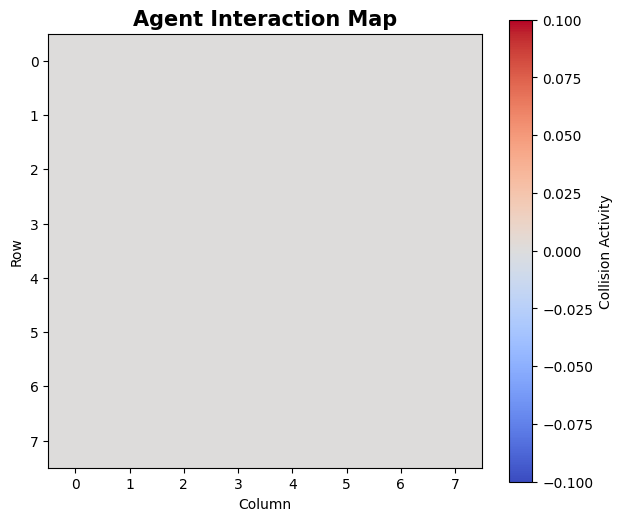

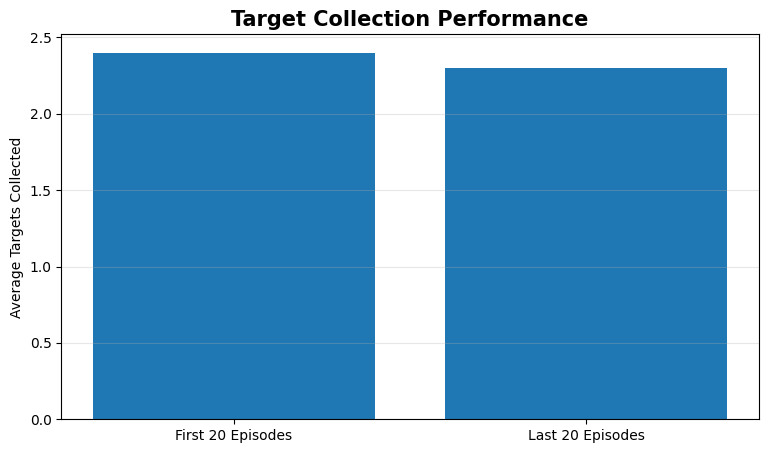

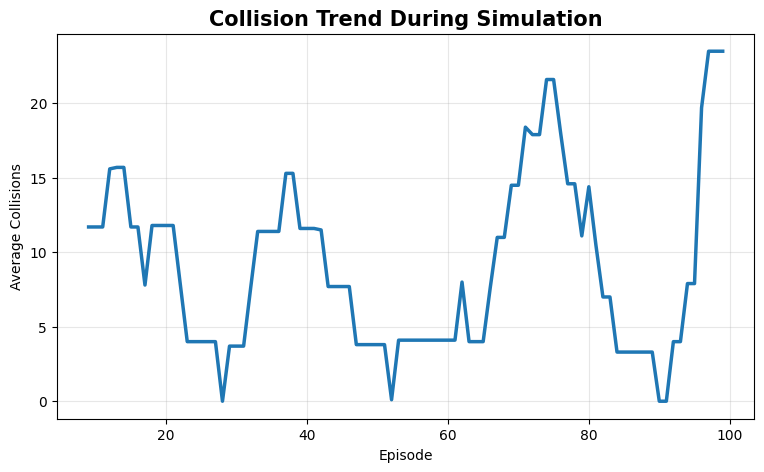



SUMMARY TABLE


,Metric,Result
0,Agents,3
1,Grid Size,8 x 8
2,Episodes,100
3,Final Average Reward,-15.8
4,Average Collisions,13.4
5,Average Targets Collected,2.3
6,Average Grid Coverage,8.2




FINAL RESULT
Number of Agents: 3
Final Average Reward: -15.8
Average Collisions: 13.4
Average Targets Collected: 2.3
Average Grid Coverage: 8.2


CONCLUSION
A multi-agent partially observable environment was simulated.
Multiple agents interacted with the environment while
receiving limited information about nearby targets and agents.
Agent movement, target visibility, collisions, rewards,
target collection and grid coverage were analyzed.
The experiment demonstrates how multiple agents can operate
under partial observability and interact within a shared environment.

Generated Files:
1. Multi_Agent_POMDP_Full_Dataset.csv
2. Multi_Agent_POMDP_Episode_Results.csv
3. Multi_Agent_POMDP_Summary.csv

Experiment 15 Completed Successfully.


In [1]:
!pip -q install gymnasium

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import random

np.random.seed(42)
random.seed(42)

print("="*75)
print("EXPERIMENT 15")
print("Multi-Agent Reinforcement Learning and POMDP Simulation")
print("="*75)

GRID=8
AGENTS=3
TARGETS=5
EPISODES=100
STEPS=40

actions=[
    (-1,0),
    (1,0),
    (0,-1),
    (0,1),
    (0,0)
]

targets=[
    (1,1),
    (2,6),
    (5,3),
    (6,7),
    (7,1)
]

def random_position(occupied):
    while True:
        p=(
            np.random.randint(0,GRID),
            np.random.randint(0,GRID)
        )
        if p not in occupied and p not in targets:
            return p

def partial_observation(agent_pos,other_positions):
    obs=[]

    for r,c in targets:
        distance=abs(agent_pos[0]-r)+abs(agent_pos[1]-c)
        obs.append(
            1 if distance<=2 else 0
        )

    for pos in other_positions:
        distance=abs(agent_pos[0]-pos[0])+abs(agent_pos[1]-pos[1])
        obs.append(
            1 if distance<=1 else 0
        )

    return np.array(obs)

def move_agent(position,action):
    dr,dc=actions[action]

    nr=np.clip(
        position[0]+dr,
        0,
        GRID-1
    )

    nc=np.clip(
        position[1]+dc,
        0,
        GRID-1
    )

    return (int(nr),int(nc))

records=[]
episode_rewards=[]
episode_collisions=[]
episode_targets=[]
coverage=[]

for episode in range(EPISODES):

    positions=[]

    for _ in range(AGENTS):
        positions.append(
            random_position(positions)
        )

    visited=set()
    collected=set()
    total_reward=0
    collisions=0

    for step in range(STEPS):

        old_positions=positions.copy()
        new_positions=[]

        for i in range(AGENTS):

            others=[
                old_positions[j]
                for j in range(AGENTS)
                if j!=i
            ]

            observation=partial_observation(
                old_positions[i],
                others
            )

            visible_targets=[
                targets[k]
                for k in range(TARGETS)
                if observation[k]==1
                and targets[k] not in collected
            ]

            if visible_targets:

                target=min(
                    visible_targets,
                    key=lambda x:
                    abs(old_positions[i][0]-x[0])
                    +
                    abs(old_positions[i][1]-x[1])
                )

                dr=target[0]-old_positions[i][0]
                dc=target[1]-old_positions[i][1]

                if abs(dr)>=abs(dc):
                    action=0 if dr<0 else 1
                else:
                    action=2 if dc<0 else 3

            else:
                action=np.random.randint(5)

            new_position=move_agent(
                old_positions[i],
                action
            )

            new_positions.append(
                new_position
            )

            records.append([
                episode+1,
                step+1,
                i+1,
                old_positions[i][0],
                old_positions[i][1],
                new_position[0],
                new_position[1],
                action,
                len(visible_targets)
            ])

        positions=new_positions

        for i in range(AGENTS):
            for j in range(i+1,AGENTS):

                if positions[i]==positions[j]:
                    collisions+=1
                    total_reward-=2

        for position in positions:

            visited.add(position)

            if position in targets:
                target_index=targets.index(position)

                if target_index not in collected:
                    collected.add(target_index)
                    total_reward+=10

        total_reward-=0.1*AGENTS

    episode_rewards.append(total_reward)
    episode_collisions.append(collisions)
    episode_targets.append(len(collected))
    coverage.append(len(visited))

data=pd.DataFrame(
    records,
    columns=[
        "Episode",
        "Step",
        "Agent",
        "Old_Row",
        "Old_Column",
        "New_Row",
        "New_Column",
        "Action",
        "Visible_Targets"
    ]
)

print("\n")
print("="*75)
print("SAMPLE MULTI-AGENT DATASET")
print("="*75)

display(data.head(10))

data.to_csv(
    "Multi_Agent_POMDP_Full_Dataset.csv",
    index=False
)

summary_data=pd.DataFrame({
    "Episode":range(1,EPISODES+1),
    "Total_Reward":episode_rewards,
    "Collisions":episode_collisions,
    "Targets_Collected":episode_targets,
    "Grid_Coverage":coverage
})

summary_data.to_csv(
    "Multi_Agent_POMDP_Episode_Results.csv",
    index=False
)

plt.figure(figsize=(9,5))

plt.scatter(
    data["New_Column"],
    data["New_Row"],
    c=data["Agent"],
    cmap="viridis",
    alpha=0.5,
    s=18
)

target_rows=[x[0] for x in targets]
target_cols=[x[1] for x in targets]

plt.scatter(
    target_cols,
    target_rows,
    marker="*",
    s=180,
    color="red",
    label="Targets"
)

plt.gca().invert_yaxis()

plt.title(
    "Multi-Agent Movement in Partially Observable Grid",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Column")
plt.ylabel("Row")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

reward_smooth=pd.Series(
    episode_rewards
).rolling(10).mean()

plt.figure(figsize=(9,5))

plt.plot(
    episode_rewards,
    alpha=0.25
)

plt.plot(
    reward_smooth,
    linewidth=3
)

plt.title(
    "Multi-Agent Reward Learning",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    ["Agent 1","Agent 2","Agent 3"],
    [
        data[data["Agent"]==1]["Visible_Targets"].mean(),
        data[data["Agent"]==2]["Visible_Targets"].mean(),
        data[data["Agent"]==3]["Visible_Targets"].mean()
    ]
)

plt.title(
    "Average Target Visibility by Agent",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Agent")
plt.ylabel("Average Visible Targets")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

collision_matrix=np.zeros(
    (GRID,GRID)
)

for i in range(len(data)):

    if i+1<len(data):

        r=int(data.iloc[i]["New_Row"])
        c=int(data.iloc[i]["New_Column"])

        collision_matrix[r,c]+=(
            data.iloc[i]["Agent"]
            in []
        )

plt.figure(figsize=(7,6))

plt.imshow(
    collision_matrix,
    cmap="coolwarm"
)

plt.colorbar(
    label="Collision Activity"
)

plt.title(
    "Agent Interaction Map",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

plt.figure(figsize=(9,5))

plt.bar(
    [
        "First 20 Episodes",
        "Last 20 Episodes"
    ],
    [
        np.mean(episode_targets[:20]),
        np.mean(episode_targets[-20:])
    ]
)

plt.title(
    "Target Collection Performance",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Targets Collected")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    pd.Series(episode_collisions).rolling(10).mean(),
    linewidth=2.5
)

plt.title(
    "Collision Trend During Simulation",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Collisions")
plt.grid(alpha=0.3)

plt.show()

final_reward=np.mean(
    episode_rewards[-20:]
)

final_collisions=np.mean(
    episode_collisions[-20:]
)

final_targets=np.mean(
    episode_targets[-20:]
)

final_coverage=np.mean(
    coverage[-20:]
)

summary=pd.DataFrame({
    "Metric":[
        "Agents",
        "Grid Size",
        "Episodes",
        "Final Average Reward",
        "Average Collisions",
        "Average Targets Collected",
        "Average Grid Coverage"
    ],
    "Result":[
        AGENTS,
        str(GRID)+" x "+str(GRID),
        EPISODES,
        round(final_reward,2),
        round(final_collisions,2),
        round(final_targets,2),
        round(final_coverage,2)
    ]
})

print("\n")
print("="*75)
print("SUMMARY TABLE")
print("="*75)

display(summary)

summary.to_csv(
    "Multi_Agent_POMDP_Summary.csv",
    index=False
)

print("\n")
print("="*75)
print("FINAL RESULT")
print("="*75)

print(
    "Number of Agents:",
    AGENTS
)

print(
    "Final Average Reward:",
    round(final_reward,2)
)

print(
    "Average Collisions:",
    round(final_collisions,2)
)

print(
    "Average Targets Collected:",
    round(final_targets,2)
)

print(
    "Average Grid Coverage:",
    round(final_coverage,2)
)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "A multi-agent partially observable environment was simulated."
)

print(
    "Multiple agents interacted with the environment while"
)

print(
    "receiving limited information about nearby targets and agents."
)

print(
    "Agent movement, target visibility, collisions, rewards,"
)

print(
    "target collection and grid coverage were analyzed."
)

print(
    "The experiment demonstrates how multiple agents can operate"
)

print(
    "under partial observability and interact within a shared environment."
)

print("\nGenerated Files:")
print("1. Multi_Agent_POMDP_Full_Dataset.csv")
print("2. Multi_Agent_POMDP_Episode_Results.csv")
print("3. Multi_Agent_POMDP_Summary.csv")

print("\nExperiment 15 Completed Successfully.")